# **Project 1 AUTOENCODERS**
**DEEP LEARNING**


### Dataset

# **Data Preparation**

In [21]:
# libraries
import random
import numpy as np
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.layers import Input, Flatten, Dense, Reshape, Conv2D, MaxPooling2D, Conv2DTranspose, UpSampling2D
from tensorflow.keras.models import Model

### **Resizing**
Our images come from different sources and have different sizes, they will be all set to 32 x 32

Total images: 1000
All images resized to: (32, 32)


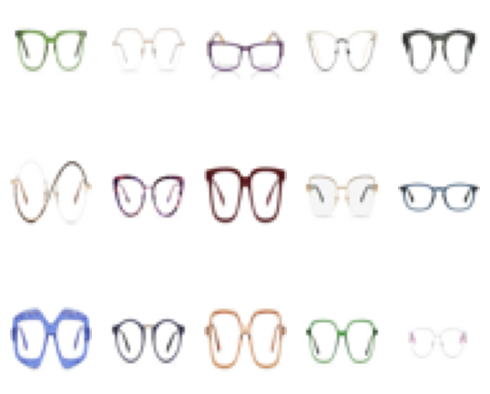

In [22]:
# getting the images
data_dir = Path("../data/raw")
image_paths = image_paths = (
    list(data_dir.glob("*.jpeg")) +
    list(data_dir.glob("*.jpg"))
)
print("Total images:", len(image_paths))

# target size
SIZE = (32, 32)

# resize all images into a list
images_resized = [Image.open(p).resize(SIZE) for p in image_paths]

print("All images resized to:", SIZE)

# show sample
sample = random.sample(images_resized, 15)

fig, axes = plt.subplots(3, 5, figsize=(5, 5))
axes = axes.flatten()

for ax, img in zip(axes, sample):
    ax.imshow(img)
    ax.axis("off")

plt.tight_layout()
plt.show()

### **Normalization**

We are converting the image arrays to `float32` and normalizing them by dividing by 255, since RGB color images have pixel values ranging from 0 to 255. This scales the data to the [0, 1] range, which improves numerical stability and helps the autoencoder train more efficiently.

In [23]:
# Convert the list of images to a NumPy array for splitting
images_np = np.array(images_resized)

# Normalize to [0, 1]
images_norm = tf.cast(images_np, tf.float32) / 255.0
images_norm = images_norm.numpy()          # back to numpy for sklearn split

### **Train Test and Validation split**
The resized images are converted to a NumPy array and split into 80% training, 10% validation, and 10% test sets with a fixed random_state for reproducibility. For our experiments, the training set learns from these samples, the validation set tunes and monitors the model, and the test set evaluates final performance and is held for the final inspection.

In [24]:
# 80 / 10 / 10 split

# First cut: 80 % train, 20 % temp
X_train, X_temp = train_test_split(images_norm, test_size=0.20, random_state=42)
# Second cut: split the 20 % temp equally into val and test
X_val, X_test   = train_test_split(X_temp,      test_size=0.50, random_state=42)

print(f'Train : {X_train.shape}')   # (800, 32, 32, 3)
print(f'Val   : {X_val.shape}')     # (100, 32, 32, 3)
print(f'Test  : {X_test.shape}')    # (100, 32, 32, 3)

Train : (800, 32, 32, 3)
Val   : (100, 32, 32, 3)
Test  : (100, 32, 32, 3)


Funtion to show our reconstructions and loss

In [25]:
def show_reconstructions(model, data, n=8, title=''):
    """Plot n original / reconstructed pairs from data."""
    reconstructed = model.predict(data[:n])
    fig, axes = plt.subplots(2, n, figsize=(n * 1.8, 4))
    fig.suptitle(title, fontsize=13, fontweight='bold')
    for i in range(n):
        axes[0, i].imshow(data[i])
        axes[0, i].axis('off')
        axes[0, i].set_title('Original', fontsize=7)
        axes[1, i].imshow(np.clip(reconstructed[i], 0, 1))
        axes[1, i].axis('off')
        axes[1, i].set_title('Reconstructed', fontsize=7)
    plt.tight_layout()
    plt.show()


def plot_loss(history, title='Training Loss'):
    """Plot training and validation loss curves."""
    plt.figure(figsize=(8, 4))
    plt.plot(history.history['loss'],     label='Train loss')
    plt.plot(history.history['val_loss'], label='Val loss')
    plt.title(title)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.tight_layout()
    plt.show()

# **Model 1**
## **Deep** (Fully-Connected) **Autoencoder**

The model first flattens the image into a 1-D vector, progressively reduces dimensionality through stacked Dense layers, compresses the representation into an 8-dimensional latent vector, and then mirrors the architecture to reconstruct the original image.

This was our simplest AE yet we had to keep making changes to it, since we got with millions of parameters when we started, this was fixed reducing the dimensionality of our first layer and our latent space.

**Architecture Overview**

| Component      | Dimensions               | Purpose                                               |
| ------------ | ------------------------ | -------------------------------------------------- |
| Input        | 32×32×3 = 3072           | Raw pixel values                                   |
| Encoder      | 3072 → 128 → 64 → 16     | Progressive compression                            |
| Latent Space | 8                        | Highly compressed representation                   |
| Decoder      | 8 → 16 → 64 → 128 → 3072 | Symmetric reconstruction                           |
| Output       | 32×32×3                  | Reconstructed image                                |


**Layers Design**

Flatten
Converts the 3D image tensor (32, 32, 3) into a 3072-dimensional vector so it can be processed by fully connected layers.

Dense(N, activation='relu')
Each hidden layer reduces dimensionality progressively.
ReLU is computationally efficient and helps mitigate vanishing gradient issues.

Dense(8) (Latent Space)
This is the core compressed representation.
No activation is applied, allowing the latent space to exist in an unconstrained continuous real-valued space.

Symmetric Decoder
Mirrors the encoder structure to gradually expand the compressed representation back to the original dimensionality.

Dense(3072, activation='sigmoid')
Sigmoid constrains the reconstructed output to the range [0, 1], matching normalized pixel values.

Reshape((32,32,3))
Restores the flattened output vector into image format for visualization and evaluation.


In [26]:
# Deep Fully-Connected Autoencoder

encoder_input = Input(shape=(32, 32, 3), name='encoder_input')

x = Flatten()(encoder_input) # flatten image to 1D vector

#  Encoder
x = Dense(128, activation='relu')(x) #compress to 128 
x = Dense(64,  activation='relu')(x) #compress to 64 
x = Dense(16,  activation='relu')(x) #compress to 16 

# Latent Space
latent_space = Dense(8, name='latent_space')(x) # latent space of 8

# Decoder
x = Dense(16, activation='relu')(latent_space) # expand back to 16
x = Dense(64, activation='relu')(x) # expand back to 64
x = Dense(128, activation='relu')(x) # expand back to 128

x = Dense(32 * 32 * 3, activation='sigmoid')(x) # final vector for all pixels (0-1)

decoder_output = Reshape((32, 32, 3))(x) # reshape back to (32,32,3) image

deep_ae = Model(encoder_input, decoder_output, name='DeepAutoencoder') # assemble model

deep_ae.compile(optimizer='adam', loss='binary_crossentropy')

deep_ae.summary()

Model: "DeepAutoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │       393,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_space (Dense)            │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 3072)           │       396,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 32, 32, 3)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 808,616 (3.08 MB)

 Trainable params: 808,616 (3.08 MB)

 Non-trainable params: 0 (0.00 B)

In [27]:
# Train the model
history_deep = deep_ae.fit(
    X_train, X_train,             
    epochs=50,
    batch_size=32,
    shuffle=True,
    validation_data=(X_val, X_val)
)

Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.3326 - val_loss: 0.1975
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1938 - val_loss: 0.1936
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1890 - val_loss: 0.1906
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1869 - val_loss: 0.1878
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1842 - val_loss: 0.1856
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1823 - val_loss: 0.1863
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1806 - val_loss: 0.1838
Epoch 8/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1793 - val_loss: 0.1828
Epoch 9/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1775 - val_loss: 0.1795
Epoch 10/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1746 - val_loss: 0.1785
Epoch 11/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1728 - val_loss: 0.1765
Epoch 12/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1718 - val_l

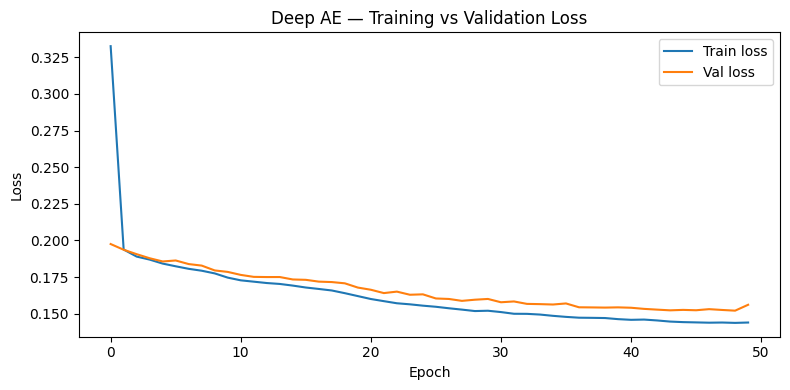

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step


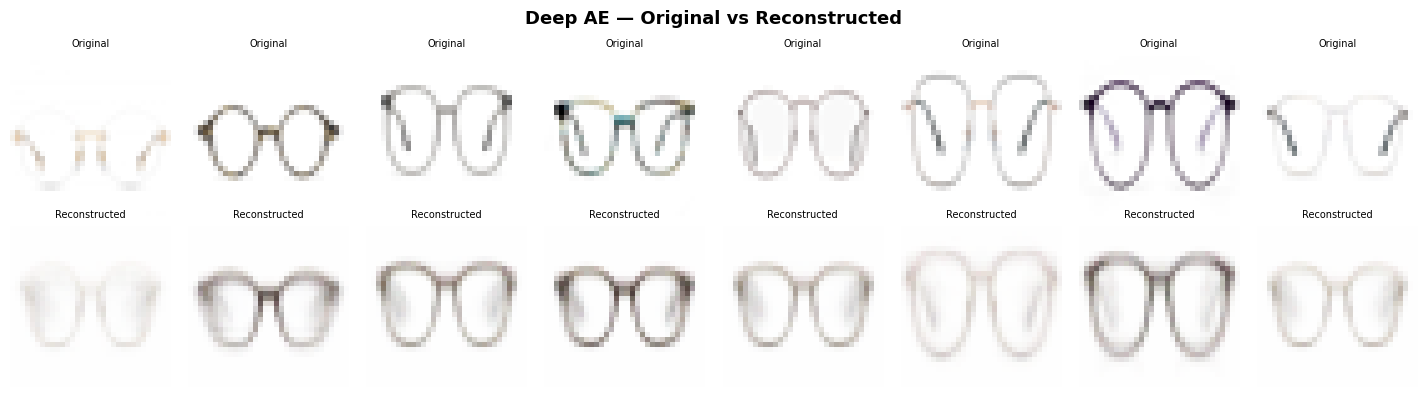

In [28]:
# Plot loss curves and reconstructions
plot_loss(history_deep, title='Deep AE — Training vs Validation Loss')
show_reconstructions(deep_ae, X_test, title='Deep AE — Original vs Reconstructed')

# **Model 2**
## **Convolutional Autoencoder** (CAE)

For this project, a convolutional autoencoder (CAE) is a more suitable choice than a fully connected architecture. Dense layers process every pixel independently and do not account for the spatial relationships that define images. As a result, they often require a large number of parameters to learn even simple visual patterns. 

We saw a huge jump from 808,616 parameters (That were already very hard to get this low), down to 75,651 parameters, making this Convolutional autoencoder much more efficient.

Convolutional layers are specifically designed for image data: they share weights across spatial locations and learn local patterns such as edges, textures, and shapes. This not only reduces the total number of trainable parameters but also allows the model to better preserve structural information during reconstruction. Consequently, a CAE typically produces sharper and more visually coherent outputs while remaining computationally efficient for images of this size and we noticed it on our graphs below.

### **Architecture**

**Encoder**
| Layer | Output shape | Purpose |
|---|---|---|
| Conv2D 32 × (3×3), ReLU, same | 32×32×32 | Detects low-level features (edges, colours); `same` padding keeps spatial dims |
| MaxPool2D 2×2 | 16×16×32 | Halves spatial resolution; keeps the strongest activations |
| Conv2D 64 × (3×3), ReLU, same | 16×16×64 | Learns higher-level patterns |
| MaxPool2D 2×2 | 8×8×64 | Further downsampling → **latent space** |

**Decoder**
| Layer | Output shape | Purpose |
|---|---|---|
| Conv2DTranspose 64 × (3×3), ReLU, same | 8×8×64 | Learnable upsampling (better than bilinear) |
| UpSampling2D 2×2 | 16×16×64 | Doubles spatial resolution |
| Conv2DTranspose 32 × (3×3), ReLU, same | 16×16×32 | Refines features |
| UpSampling2D 2×2 | 32×32×32 | Restores original resolution |
| Conv2DTranspose 3 × (3×3), **Sigmoid**, same | 32×32×3 | Final RGB output in [0,1] |


In [29]:
encoder_input = Input(shape=(32, 32, 3))

#  Encoder
# First conv block : detect low-level features (edges, colour blobs)
x = Conv2D(32, (3, 3), activation='relu', padding='same')(encoder_input)  # (32,32,32)
x = MaxPooling2D((2, 2))(x)                                      # (16,16,32)

# Second conv block : detect higher-level patterns
x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)    # (16,16,64)
encoded = MaxPooling2D((2, 2))(x)                                # (8,8,64)  latent space (bottleneck)

# Decoder
# Mirror block 2
x = Conv2DTranspose(64, (3, 3), activation='relu', padding='same')(encoded)  # (8,8,64)
x = UpSampling2D((2, 2))(x)                                                   # (16,16,64)

# Mirror block 1
x = Conv2DTranspose(32, (3, 3), activation='relu', padding='same')(x)        # (16,16,32)
x = UpSampling2D((2, 2))(x)                                                   # (32,32,32)

# Output layer : 3 channels with sigmoid to match [0,1] normalisation
decoded = Conv2DTranspose(3, (3, 3), activation='sigmoid', padding='same')(x) # (32,32,3)

conv_ae = Model(encoder_input, decoded, name='Conv_AE')
conv_ae.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                loss='binary_crossentropy')
conv_ae.summary()

Model: "Conv_AE"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_12             │ (None, 8, 8, 64)       │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_8 (UpSampling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_13             │ (None, 16, 16, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_9 (UpSampling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_14             │ (None, 32, 32, 3)      │           867 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 75,651 (295.51 KB)

 Trainable params: 75,651 (295.51 KB)

 Non-trainable params: 0 (0.00 B)

In [30]:
# Train the model
history_conv = conv_ae.fit(
    X_train, X_train,
    epochs=50,
    batch_size=32,
    shuffle=True,
    validation_data=(X_val, X_val)
)

Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.3805 - val_loss: 0.2834
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.2530 - val_loss: 0.2182
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.2016 - val_loss: 0.1891
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1780 - val_loss: 0.1722
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1652 - val_loss: 0.1636
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1583 - val_loss: 0.1584
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1538 - val_loss: 0.1546
Epoch 8/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1500 - val_loss: 0.1541
Epoch 9/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1470 - val_loss: 0.1481
Epoch 10/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1441 - val_loss: 0.1460
Epoch 11/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1422 - val_loss: 0.1430
Epoch 12/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1

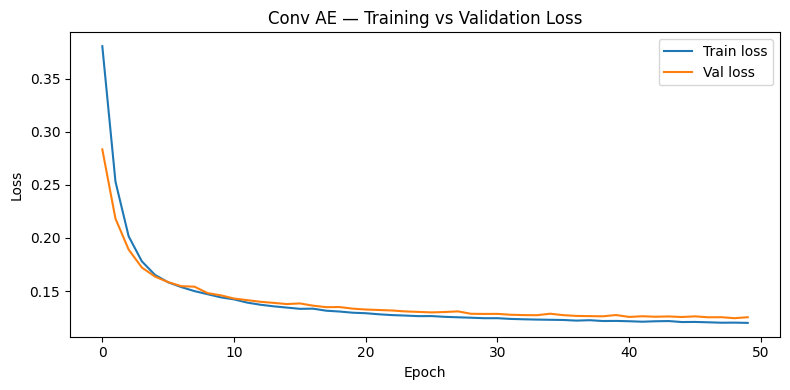

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step


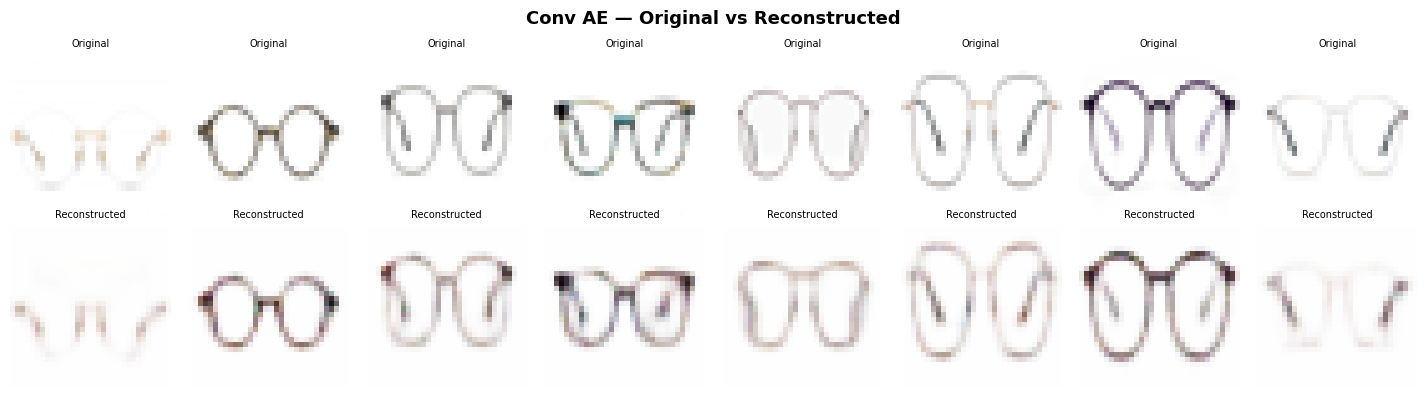

In [31]:
# Plot loss curves and reconstructions
plot_loss(history_conv, title='Conv AE — Training vs Validation Loss')
show_reconstructions(conv_ae, X_test, title='Conv AE — Original vs Reconstructed')

# **Model 3**
## **Denoising Autoencoder** (DAE)


On our project, a denoising variant of the convolutional autoencoder is a natural extension. A denoising autoencoder is trained by **corrupting the input** with random noise and asking the network to reconstruct the **clean** original. This forces the encoder to learn truly meaningful structure rather than an identity mapping, acting as a regulariser and improving feature quality.

### **Noise strategy**
We corrupted the input with Gaussian noise with standard deviation stddev = 0.15. After adding noise, values are clipped to the [0,1] range so the network always sees valid pixel intensities.The chosen noise level is large enough to produce clearly corrupted examples while preserving the underlying structure the model must learn to recover; this encourages the encoder to extract robust, generalizable features

### **Architecture**
Identical to the Convolutional AE we did above the only change is that noisy images are passed as input while clean images remain the target. This demonstrates how the same architecture behaves differently depending on the training objective.

| Component    | Dimensions   | Purpose                                                                                                     |
| ------------ | -------------------------------------------------------------------------------------------------------- | ----------------------------------------------------------------------------------------------------------- |
| Input        | 32×32×3                                                                                                  | Noisy RGB image supplied to the network during training                                                     |
| Encoder      | 32×32×32 → (MaxPool) → 16×16×32 → 16×16×64 → (MaxPool) → 8×8×64                                          | Convolutional downsampling that learns local features and compresses spatial information into a compact map |
| Latent / Map | 8×8×64 (encoder output)                                                                                  | Encoded spatial feature map (the “latent” representation for CAE style)                                     |
| Decoder      | 8×8×64 → ConvTranspose/Up → 16×16×64 → ConvTranspose/Up → 32×32×32 → ConvTranspose(3, sigmoid) → 32×32×3 | Symmetric upsampling and refinement to reconstruct the RGB image in [0,1]                                   |
| Output       | 32×32×3                                                                                                  | Clean image target (ground-truth)                                                                           |

In [32]:
# ADD GAUSSIAN NOISE to training and validation inputs
noise_factor = 0.15

# tf.random.normal generates Gaussian noise with mean=0, stddev=noise_factor
X_train_noisy = X_train + tf.random.normal(shape=X_train.shape, mean=0.0,
                                            stddev=noise_factor, dtype=tf.float32)
X_val_noisy   = X_val   + tf.random.normal(shape=X_val.shape,   mean=0.0,
                                            stddev=noise_factor, dtype=tf.float32)
X_test_noisy  = X_test  + tf.random.normal(shape=X_test.shape,  mean=0.0,
                                            stddev=noise_factor, dtype=tf.float32)

# Clip to valid [0,1] range — noise can push values outside this range
X_train_noisy = tf.clip_by_value(X_train_noisy, 0.0, 1.0).numpy()
X_val_noisy   = tf.clip_by_value(X_val_noisy,   0.0, 1.0).numpy()
X_test_noisy  = tf.clip_by_value(X_test_noisy,  0.0, 1.0).numpy()

In [33]:
# Same architecture as the Model 2
encoder_input = Input(shape=(32, 32, 3))

# Encoder
x = Conv2D(32, (3, 3), activation='relu', padding='same')(encoder_input)
x = MaxPooling2D((2, 2))(x)
x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2, 2))(x)    # (8,8,64) latent space (bottleneck)

# Decoder
x = Conv2DTranspose(64, (3, 3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2, 2))(x)
x = Conv2DTranspose(32, (3, 3), activation='relu', padding='same')(x)
x = UpSampling2D((2, 2))(x)
decoded = Conv2DTranspose(3, (3, 3), activation='sigmoid', padding='same')(x)

denoise_ae = Model(encoder_input, decoded, name='Denoising_AE')
denoise_ae.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                   loss='binary_crossentropy')
denoise_ae.summary()

Model: "Denoising_AE"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_15             │ (None, 8, 8, 64)       │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_10 (UpSampling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_16             │ (None, 16, 16, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_11 (UpSampling2D) │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_17             │ (None, 32, 32, 3)      │           867 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 75,651 (295.51 KB)

 Trainable params: 75,651 (295.51 KB)

 Non-trainable params: 0 (0.00 B)

In [34]:
# Train on NOISY inputs, but the TARGET is the CLEAN image
history_denoise = denoise_ae.fit(
    X_train_noisy, X_train,
    epochs=50,
    batch_size=32,
    shuffle=True,
    validation_data=(X_val_noisy, X_val)
)

Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 0.3323 - val_loss: 0.2558
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.2224 - val_loss: 0.2015
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.1845 - val_loss: 0.1772
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.1698 - val_loss: 0.1687
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.1618 - val_loss: 0.1629
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.1567 - val_loss: 0.1577
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.1533 - val_loss: 0.1545
Epoch 8/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.1508 - val_loss: 0.1524
Epoch 9/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.1477 - val_loss: 0.1501
Epoch 10/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.1456 - val_loss: 0.1479
Epoch 11/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.1440 - val_loss: 0.1461
Epoch 12/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.1

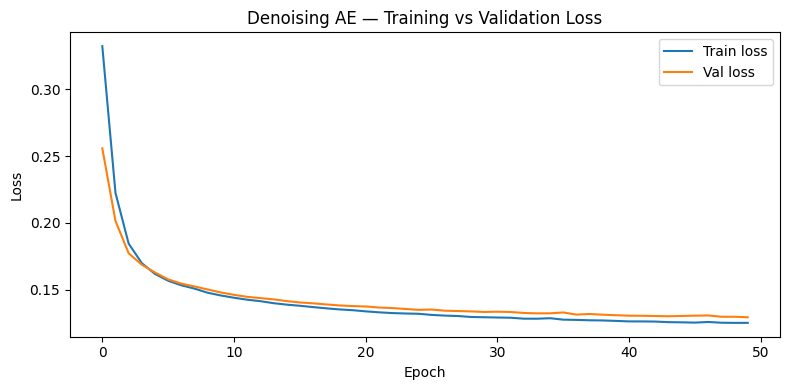

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step


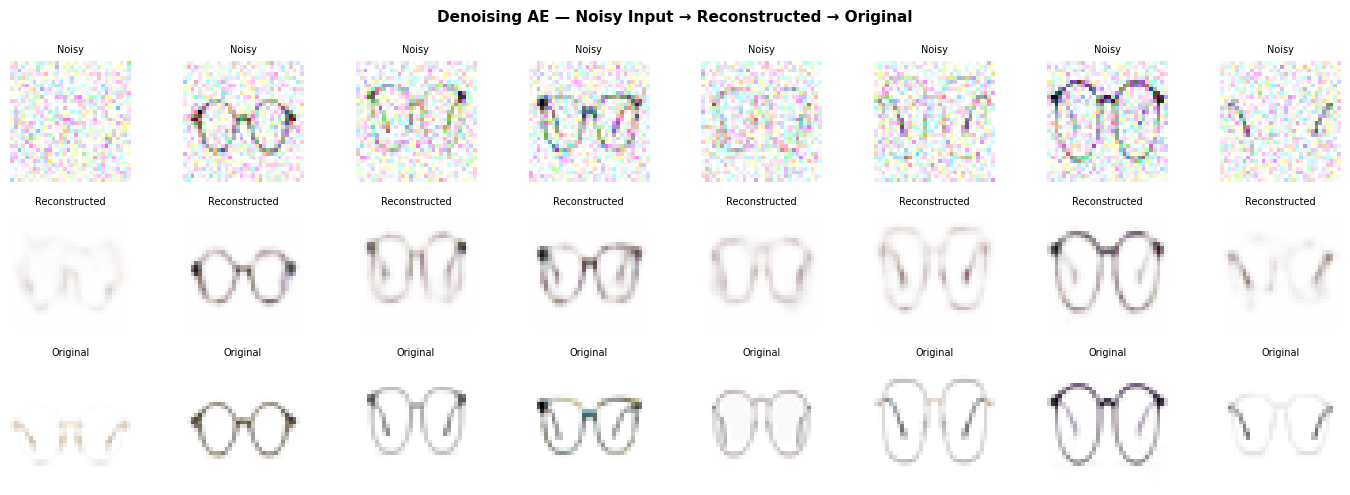

In [35]:
# Plot loss curves and reconstructions, but the reconsruction also shows the noised image

plot_loss(history_denoise, title='Denoising AE — Training vs Validation Loss')

reconstructed_clean = denoise_ae.predict(X_test_noisy[:8])

fig, axes = plt.subplots(3, 8, figsize=(14, 5))
fig.suptitle('Denoising AE — Noisy Input → Reconstructed → Original', fontsize=11, fontweight='bold')
for i in range(8):
    axes[0, i].imshow(X_test_noisy[i])
    axes[0, i].axis('off')
    axes[0, i].set_title('Noisy', fontsize=7)

    axes[1, i].imshow(np.clip(reconstructed_clean[i], 0, 1))
    axes[1, i].axis('off')
    axes[1, i].set_title('Reconstructed', fontsize=7)

    axes[2, i].imshow(X_test[i])
    axes[2, i].axis('off')
    axes[2, i].set_title('Original', fontsize=7)

plt.tight_layout()
plt.show()

# **Model 4**
## Variational Autoencoder (VAE)


### What makes a VAE different?
A standard autoencoder maps each image to a **single point** in latent space. Points between training samples are not guaranteed to decode into anything meaningful, so you can't freely sample from the space.

A VAE maps each image to a **probability distribution** — specifically a Gaussian characterised by `μ` (mean) and `log σ²` (log variance). During training the network learns to make this distribution as standard-normal-like as possible (KL term), while still reconstructing images accurately (reconstruction term). The result is a **smooth, continuous** latent space where any sampled point decodes into a plausible image.